In [ ]:
%%html
<style> 
table {display: block;} 
td {
  font-size: 18px
}
.rendered_html { font-size: 28px; }
*{ line-height: 200%; }
</style>


# Natural Language Processing and the Web WS 2025/26- Practice Class - <span style="color:blue">Week 05</span>

In this practice class, we will explore core methods for supervised machine learning in NLP, with a special focus on using <span style="color:blue"><b>PyTorch</b></span> for building, training, and evaluating neural models.

Throughout this practice, you'll deepen your understanding of:

- <span style="color:blue"><b>Supervised Learning</b></span> and <span style="color:blue"><b>Feature Engineering</b></span>: How text data can be represented and turned into features for machine learning models.
- <span style="color:blue"><b>PyTorch Essentials</b></span>: The foundations of deep learning with PyTorch, including tensors, computation graphs, neural network modules, and training workflows for NLP.
- <span style="color:blue"><b>End-to-End ML/NLP Pipelines</b></span>: From data preprocessing and feature extraction to model training and deployment basics.

## Contents

1. <span style="color:blue"><b>Foundations of PyTorch for NLP & Machine Learning</b></span>
2. <span style="color:blue"><b>Text Representation & Feature Engineering</b></span> 
3. <span style="color:blue"><b>Building, Training, and Evaluating Neural Models for NLP Tasks</b></span>

---


# Foundations of <span style="color:blue"><b>PyTorch</b></span> for <span style="color:blue"><b>NLP & Machine Learning</b></span>

---

<span style="color:blue"><b>PyTorch</b></span> is one of the leading frameworks for developing modern neural network models in <span style="color:blue"><b>Natural Language Processing (NLP)</b></span> and <span style="color:blue"><b>Machine Learning (ML)</b></span>. Its popularity comes from:

- <span style="color:blue"><b>Dynamic computation graphs</b></span> ("define-by-run" paradigm)
- A user-friendly <span style="color:blue"><b>Pythonic interface</b></span>
- Effortless integration with <span style="color:blue"><b>NumPy</b></span>, <span style="color:blue"><b>GPU acceleration</b></span>, and the broader Python ecosystem

## PyTorch and Tensors in NLP

PyTorch is a Python-based deep learning library that allows you to build, train, and deploy modern machine learning models. It is designed for both rapid prototyping and high performance, supporting both CPUs and GPUs transparently.

<span style="color:blue">A Tensor is PyTorch's fundamental data structure.</span> It is similar to a NumPy array, but adds extra features:
- Run on CPU <b>and</b> GPU (seamlessly!)
- Support for <span style="color:blue">automatic differentiation</span> (needed for neural networks)
- Efficient mathematical operations for scientific computing
- Interoperates smoothly with NumPy and other scientific Python libraries

You can run PyTorch locally or on <a href="https://colab.research.google.com/">Google Colab</a> for free GPU access (<span style="color:blue">highly recommended for larger models</span>).

# <span style="color:blue">Tensors</span>
Tensors are similar to Numpy, that are used to create n-dimensional arrays --> Matrices
![alt Tensors](https://www.learnopencv.com/wp-content/uploads/2019/05/PyTorch-Tensors.jpg)

In [1]:
import torch
import numpy as np

# 1D  --> 10 ones
ones_vector = torch.ones(10)
print("Ones vector:", ones_vector)

# 2D 
zeros_matrix = torch.zeros(2, 3)
print("Zeros matrix:\n", zeros_matrix)

# from a Python list 
float_tensor = torch.tensor([0.1, 0.2, 0.3], dtype=torch.float64)
print("64-bit float tensor:", float_tensor)

# Tensor to NumPy and back
arr = ones_vector.numpy()
print("Converted to NumPy:", arr)
tensor_again = torch.from_numpy(arr)
print("Back to tensor:", tensor_again)

Ones vector: tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])
Zeros matrix:
 tensor([[0., 0., 0.],
        [0., 0., 0.]])
64-bit float tensor: tensor([0.1000, 0.2000, 0.3000], dtype=torch.float64)
Converted to NumPy: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
Back to tensor: tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])


<span style="color:blue">Exploring Tensors: Indexing, Arithmetic, and Data Types</span>

PyTorch tensors work much like NumPy arrays and support powerful indexing and arithmetic.

<span style="color:blue">Need to extract specific values or slices? Want to add or multiply tensors?</span> It’s easy:

- <span style="color:blue">Indexing</span>: Access rows, columns, or slices—just like NumPy!
- <span style="color:blue">Arithmetic</span>: All Python arithmetic operators (+, -, *, /, **, ...).
- <span style="color:blue">Data types</span>: You can set dtypes (int, float32, float64, etc.).
- <span style="color:blue">Tensor ↔️ NumPy</span>: Move data back and forth seamlessly.


In [ ]:
b = torch.tensor([[1,2,3],
                  [4,5,6],
                  [7,8,9],
                  [10,11,12]],dtype=torch.float32)
print("b =\n", b)
print("b.shape =", b.shape)
# indexing
print("Row 2:", b[2])            # third row
print("Rows 0 and 1:", b[:2])    # first two rows
print("Column 2:", b[:,2])       # third column
# elementwise
print("Row 2 + 2:", b[2] + 2)
# matrix multiplication
c = torch.tensor([[1., 2.], [3., 4.], [5., 6.]])
print("matrix mult:\n", torch.mm(b, c))
# type specification
a = torch.tensor([1,2,3], dtype=torch.int32)
print("Int32 tensor:", a)
f = torch.tensor([2., 4., 6.], dtype=torch.float64)
print("Float64 tensor:", f)

b =
 tensor([[ 1.,  2.,  3.],
        [ 4.,  5.,  6.],
        [ 7.,  8.,  9.],
        [10., 11., 12.]])
b.shape = torch.Size([4, 3])
Row 2: tensor([7., 8., 9.])
Rows 0 and 1: tensor([[1., 2., 3.],
        [4., 5., 6.]])
Column 2: tensor([ 3.,  6.,  9., 12.])
Row 2 + 2: tensor([ 9., 10., 11.])
matrix mult:
 tensor([[ 22.,  28.],
        [ 49.,  64.],
        [ 76., 100.],
        [103., 136.]])
Int32 tensor: tensor([1, 2, 3], dtype=torch.int32)
Float64 tensor: tensor([2., 4., 6.], dtype=torch.float64)


<span style="color:blue">Tip: PyTorch requires that both matrices have the same dtype for matrix multiplication—typically use <b>float32</b> for neural network data!</span>

<span style="color:blue"><b>Using CPU and GPU in PyTorch</b></span>

PyTorch lets you run code on either your computer's <span style="color:blue"><b>CPU</b></span> or a <span style="color:blue"><b>GPU</b></span> (if available), which speeds up training large models a lot.

- <span style="color:blue">Check <code>torch.cuda.is_available()</code> to see if you have an NVIDIA GPU.</span>
- <span style="color:blue">Apple Silicon (M1/M2) users: PyTorch supports Apple's Metal Performance Shader (MPS).</span>
- On Google Colab, just switch to "GPU" in Runtime ▶ Change runtime type.
- Move tensors with <code>.to(device)</code>.

<span style="color:blue">⚡️ You can always check what device a tensor is on by printing <code>tensor.device</code>.</span>


In [ ]:
import torch
x = torch.ones(3)
print("Initial device:", x.device)
# Detect device
if torch.cuda.is_available():
    device = torch.device("cuda")
    print("CUDA GPU found!")
elif getattr(torch.backends, "mps", None) is not None and torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Apple Silicon (MPS) GPU found!")
else:
    device = torch.device("cpu")
    print("No GPU found, using CPU.")
# Move tensor to chosen device
x = x.to(device)
print("Now on device:", x.device)

Initial device: cpu
Apple Silicon (MPS) GPU found!
Now on device: mps:0


---

<span style="color:red"><b>EXERCISE</b></span>:  
<span style="color:red">Create a random tensor of shape (4, 3).  
- Print its shape.  
- Multiply it (element-wise) by a tensor of `ones` of the same shape.  
- Sum over all elements.</span>

---

In [3]:
EXERCISE=True

In [4]:
if EXERCISE:
    import torch

    #  random tensor of shape (4, 3)
    x = torch.randn(4, 3)

    # its shape
    print("Shape:", x.shape)

    # element-wise multipolication by a tensor of ones of the same shape
    result = x * torch.ones(4, 3)   

    # Sum over all elements
    total = result.sum()

    print("Result of element-wise multiplication:\n", result)
    print("Sum of all elements:", total)


Shape: torch.Size([4, 3])
Result of element-wise multiplication:
 tensor([[ 2.4692, -0.8064,  0.3863],
        [-0.3955,  1.5483,  0.0218],
        [-0.7293, -0.9328,  0.5821],
        [ 0.0164, -0.7193,  0.2863]])
Sum of all elements: tensor(1.7272)


<span style="color:blue"><b>Why Are Gradients Important in PyTorch?</b></span>

Gradients let PyTorch automatically compute derivatives for neural network training.  
<span style="color:blue">When you set <code>requires_grad=True</code>, PyTorch builds a computation graph for every operation.</span>  
When you call <code>.backward()</code> on a scalar result, it computes <span style="color:blue">gradients for all tensors that require them</span>.  
This is what powers all neural network training!

In [6]:
import torch

a = torch.ones((2, 2), requires_grad=True)
print("a =", a)
b = a + 5
print("b =", b)
c = b.mean()
print("c = mean(b) =", c)

print(c.shape)
# gradients w.r.t. a
c.backward()
print("Gradients of c w.r.t. a:", a.grad) # Partial derivatives of c w.r.t a dc / da = 1/4 = 0.25

a = tensor([[1., 1.],
        [1., 1.]], requires_grad=True)
b = tensor([[6., 6.],
        [6., 6.]], grad_fn=<AddBackward0>)
c = mean(b) = tensor(6., grad_fn=<MeanBackward0>)
torch.Size([])
Gradients of c w.r.t. a: tensor([[0.2500, 0.2500],
        [0.2500, 0.2500]])


<span style="color:blue"><b>Activation functions: nonlinear building blocks for neural networks</b></span> (<span style="color:red">more details below </span>)

Activation functions help neural networks learn complex, non-linear patterns in data.  
<span style="color:blue"><b>But which one to use?</b></span>  
Here’s a summary:

| Name        | Output Range | Typical Use                              |
|-------------|-------------|------------------------------------------|
| Sigmoid     | (0, 1)      | Binary classification output layer       |
| Tanh        | (-1, 1)     | Sometimes for output or mid-layer        |
| ReLU        | [0, ∞)      | Hidden layers (most common!)             |
| Softmax     | (0, 1)      | Multi-class probability output           |

<span style="color:blue">
<b>ReLU</b> is now the typical choice for hidden layers: it helps with gradient flow and trains quickly.
</span>

<span style="color:blue"><b>Loss functions: measuring how good our model is</b></span> (<span style="color:red">more details below </span>)

Loss functions tell us how well the model’s predictions match the target values.  
<span style="color:blue"><b>Which loss to use?</b></span>

| Function          | Use for...                          | Comments                  |
|-------------------|-------------------------------------|---------------------------|
| MSELoss           | Regression (real-valued targets)    | Squared error             |
| CrossEntropyLoss  | Multi-class classification          | Combines LogSoftmax + NLL |
| BCELoss           | Binary classification               | Inputs should be probs    |

<span style="color:blue"><b>Text Preprocessing: Why clean and vectorize?</b></span>

Real-world text data is <span style="color:blue">messy, inconsistent, and noisy</span>. Good preprocessing helps your model:
- Improve accuracy,
- Reduce overfitting,
- Generalize to new text!

<span style="color:blue">Common steps:</span>
- Lowercasing (so 'cat' = 'Cat')
- Removing extra whitespace or punctuation,
- Tokenizing into words

Let's see a simple cleaning and vocabulary extraction pipeline on a small corpus.

In [41]:
from collections import Counter
corpus = [
    "PyTorch is GREAT for NLP tasks!",
    " Spark helps with big data.",
    "NLP, Spark, together scale text processing."
]
#lowercase and remove extra whitespace
def preprocess_text(text):
    return ' '.join(text.lower().split())
corpus_clean = [preprocess_text(sent) for sent in corpus]
print("Cleaned corpus:", corpus_clean)
#  vocabulary 
vocab_counter = Counter()
for sent in corpus_clean:
    vocab_counter.update(sent.split())

print("Vocabulary size:", len(vocab_counter))
print("Sample vocabulary:", list(vocab_counter.keys())[:10])
# CountVectorizer for BoW
from sklearn.feature_extraction.text import CountVectorizer
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(corpus_clean)
print("Vocabulary (CountVectorizer):", vectorizer.get_feature_names_out())
print("BoW matrix:\n", X.toarray())

Cleaned corpus: ['pytorch is great for nlp tasks!', 'spark helps with big data.', 'nlp, spark, together scale text processing.']
Vocabulary size: 17
Sample vocabulary: ['pytorch', 'is', 'great', 'for', 'nlp', 'tasks!', 'spark', 'helps', 'with', 'big']
Vocabulary (CountVectorizer): ['big' 'data' 'for' 'great' 'helps' 'is' 'nlp' 'processing' 'pytorch'
 'scale' 'spark' 'tasks' 'text' 'together' 'with']
BoW matrix:
 [[0 0 1 1 0 1 1 0 1 0 0 1 0 0 0]
 [1 1 0 0 1 0 0 0 0 0 1 0 0 0 1]
 [0 0 0 0 0 0 1 1 0 1 1 0 1 1 0]]


<span style="color:red"><b>Exercise:</b> 
    Add your own sentence about PyTorch, re-run the vectorizer, and see what new words appear in the vocabulary. How does this affect the word-to-index mapping?</span>

In [9]:
if EXERCISE:
    from sklearn.feature_extraction.text import CountVectorizer
    corpus = [
        "PyTorch is GREAT for NLP tasks!",
        "Spark helps      with big data.",
        "NLP, Spark -- together scale    text processing."
    ]

    # New sentence hefre
    corpus.append("_____")  

    vectorizer = CountVectorizer()
    X = vectorizer.fit_transform(corpus)
    print("Vocabulary (CountVectorizer):", vectorizer.get_feature_names_out())
    print("BoW matrix:\n", X.toarray())

# Recap! <span style="color:blue"><b>Text Representation & Feature Engineering</b></span>

Many <span style="color:blue"><b>machine learning</b></span> algorithms require that data is expressed in a numeric form. For <span style="color:blue"><b>text</b></span>, this means we must “featurize” or vectorize our documents. The choice of <span style="color:blue"><b>feature</b></span> representation plays a crucial role in how well our models capture linguistic patterns.

## Common <span style="color:blue"><b>Text Representations</b></span>

- <span style="color:blue"><b>Bag-of-Words (BoW)</b></span>: Most basic, representing documents as word-count vectors.
- <span style="color:blue"><b>TF-IDF</b></span>: Adjusts word counts by their informativeness.
- <span style="color:blue"><b>Word Embeddings</b></span>: Learns dense vectors capturing semantic similarity.

## <span style="color:blue"><b>Word Embeddings: Capturing Meaning & Similarity</b></span>

Traditional bag-of-words representations ignore word order and poorly capture meaning.  
<span style="color:blue">Word embeddings are dense vectors learned so that <b>similar words have similar vectors</b>.</span>  
They let neural networks learn meaning, not just frequency!

Key points:
- Learnable & compact: each word = a trainable vector (e.g., 50-300 dimensions)
- Capture semantic similarity: (e.g. "cat", "kitten" close to each other)
- Work well as model inputs: much better than plain counts.

Let's see how easy it is to create and use embeddings in PyTorch:

In [7]:
import torch
import torch.nn as nn

# Example: pretend our vocab is size 10, vectors are length 4
embedding_dim = 4
vocab_size = 10
emb = nn.Embedding(num_embeddings=vocab_size, embedding_dim=embedding_dim)

word_indices = torch.tensor([1, 8, 3])
print("Word indices:", word_indices)
print("Word vectors:\n", emb(word_indices))

Word indices: tensor([1, 8, 3])
Word vectors:
 tensor([[ 0.1339,  1.4594, -2.6226,  0.0535],
        [ 0.7058, -1.1079, -0.3273,  0.2018],
        [ 1.0792,  0.4434,  0.4946, -0.2033]], grad_fn=<EmbeddingBackward0>)


<span style="color:red"><b>EXERCISE</b></span>:  
<span style="color:red">Given the embedding layer above, change the embedding dimension to a larger number and print out the new vector representations.  
What happens to the shape?</span>

In [8]:
if EXERCISE:
    import torch
    import torch.nn as nn

    embedding_dim = 6
    vocab_size = 10
    emb = nn.Embedding(num_embeddings=vocab_size, embedding_dim=embedding_dim)

    word_indices = torch.tensor([1, 8, 3])
    vectors = emb(word_indices)
    print("Word indices:", word_indices)
    print("Word vectors shape:", vectors.shape)
    print("Word vectors:\n", vectors)

Word indices: tensor([1, 8, 3])
Word vectors shape: torch.Size([3, 6])
Word vectors:
 tensor([[-1.1659, -0.5766,  0.4815, -0.9200,  0.5262,  0.5843],
        [-0.5248, -1.2506,  0.3144, -0.2402,  0.5082, -0.4824],
        [-0.2884,  0.7487, -0.1750,  1.2889,  1.9708,  0.1613]],
       grad_fn=<EmbeddingBackward0>)


<span style="color:blue"><b>Encoding Sentences and Documents: Pooling over Word Embeddings</b></span>

Once each word is an embedding vector,  
<span style="color:blue">how do we make a fixed-length representation for a sentence or document?</span>

<span style="color:blue">Mean pooling</span>: Take the average of all embedding vectors.  
<span style="color:blue">Max pooling</span>: Take the elementwise max.  
Both methods give you a single vector per sentence—good for simple models!

---

In [12]:
sentence = torch.tensor([2, 3, 1, 5])  # a "sentence" (seq of word indices)
embeddings = nn.Embedding(10, 8)  # vocab size 10, embedding dim 8
sentence_embeds = embeddings(sentence)
print("Shape of embedding matrix for sentence:", sentence_embeds.shape)

# Mean pooling
doc_mean = sentence_embeds.mean(dim=0)
print("Sentence vector (mean pooling):\n", doc_mean)

# Max pooling
doc_max, _ = sentence_embeds.max(dim=0)
print("Sentence vector (max pooling):\n", doc_max)

Shape of embedding matrix for sentence: torch.Size([4, 8])
Sentence vector (mean pooling):
 tensor([-0.0422,  0.1855, -0.0295,  0.1264, -0.5894, -0.4253,  0.3210, -0.2659],
       grad_fn=<MeanBackward1>)
Sentence vector (max pooling):
 tensor([ 0.8993,  0.7109,  1.6794,  0.8907, -0.1264,  0.4764,  1.6578,  1.7584],
       grad_fn=<MaxBackward0>)


<span style="color:red"><b>Exercise:</b> 
What happens if you use an embedding layer with dimension 16?  
Or if your sentence consists of 7 words?  
Print out the new shapes and explain what changed and why.</span>

In [10]:
if EXERCISE:
    import torch
    import torch.nn as nn

    embedding_dim = 5  
    vocab_size = 10
    sentence = torch.tensor([2, 3, 1, 5, 4, 2, 1]) 

    embeddings = nn.Embedding(vocab_size, embedding_dim)
    sentence_embeds = embeddings(sentence)
    print("Shape of embedding matrix for sentence:", sentence_embeds.shape)
    print(f"Sentence embedding: \n{sentence_embeds}")

Shape of embedding matrix for sentence: torch.Size([7, 5])
Sentence embedding: 
tensor([[-0.1659,  0.3315, -2.3651, -0.1236,  0.0611],
        [ 0.1861,  0.8969,  0.6713, -1.4805, -0.4006],
        [-0.8166, -0.8674,  0.1921, -1.3582,  0.7587],
        [-1.6970,  1.2439,  0.3397, -0.3428,  1.0242],
        [-0.5030,  1.4354,  0.0152, -0.1817,  0.2681],
        [-0.1659,  0.3315, -2.3651, -0.1236,  0.0611],
        [-0.8166, -0.8674,  0.1921, -1.3582,  0.7587]],
       grad_fn=<EmbeddingBackward0>)


# <span style="color:blue"><b>Sequence Models: RNNs & LSTMs</b></span>

Traditional neural networks can’t remember word order or context.  
<span style="color:blue"><b> Recurrent Neural Network (RNNs) and especially Long Short-Term Memory (LSTMs)</b> handle sequences, remembering what came before!</span>

Great for language modeling, text classification, translation, and more.

---

In [12]:
input_dim = 8
hidden_dim = 32
lstm = nn.LSTM(input_size=input_dim, hidden_size=hidden_dim, batch_first=True)

inputs = sentence_embeds.unsqueeze(0)   # shape: (batch=1, seq_len, emb_dim)
outputs, (h_n, c_n) = lstm(inputs)
print("Outputs shape [should be (batch, seq_len, hidden_dim)]:", outputs.shape)
print("Last hidden state(s):", h_n.shape)

RuntimeError: input.size(-1) must be equal to input_size. Expected 8, got 5

<span style="color:red"><b>Exercise:</b>
Suppose you batch together 5 sentences (all padded to same length).
What would the outputs.shape be?  
(Hint: batch_first=True means shape is [batch_size, seq_len, hidden_dim]!)</span>


In [15]:
if EXERCISE:
    import torch
    import torch.nn as nn

    embedding_dim = _____  
    hidden_dim = _____      
    batch_size = _____     
    seq_len = _____         

    inputs = torch.randn(batch_size, seq_len, embedding_dim)
    lstm = nn.LSTM(input_size=embedding_dim, hidden_size=hidden_dim, batch_first=True)
    outputs, (h_n, c_n) = lstm(inputs)
    print("Outputs shape:", outputs.shape)  # (batch_size, seq_len, hidden_dim)
    print("Last hidden state(s):", h_n.shape)

#  <span style="color:blue"><b>Building, Training, and Evaluating Neural Models for NLP Tasks</b></span>

Modern <span style="color:blue"><b>PyTorch</b></span> makes it straightforward to build, train, and evaluate <span style="color:blue"><b>neural networks</b></span> for <span style="color:blue"><b>NLP tasks</b></span>. This section introduces the essential components, model definition, activation functions, loss functions, optimizers, and evaluation, then puts them together in practical code for text classification.

## Defining a <span style="color:blue"><b>Neural Network Model</b></span>

In PyTorch, every neural network is defined as a subclass of <span style="color:blue"><b>nn.Module</b></span>. The <span style="color:blue"><b>forward()</b></span> method specifies the data flow.

## A typical workflow in PyTorch
![alt pytorch workflow](https://www.learnopencv.com/wp-content/uploads/2019/05/torch-workflow.png)

In [16]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class SimplePerceptron(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super().__init__()
        self.hidden = nn.Linear(input_size, hidden_size)
        self.output = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        x = F.relu(self.hidden(x))                
        x = self.output(x)                       
        return x

## Perceptron: The simplest neural network
Like a biological neuron, there is `input` and `output` where the `signals` flow from the inputs to the the outputs.

$y = f(wx +b)$

`x` is the input, `y` is the output, `wx +b` is a linear function while `f(wx+b)` is a non-linear function called the `activation function`.
![alt perceptron](https://miro.medium.com/max/2978/1*-uNOPSyB7IOk9inA-brIBg.png)

## <span style="color:blue"><b>Activation Functions</b></span> and Their Role

Activation functions introduce non-linearity—critical for learning complex natural language patterns.

These are nonlinear functions used to capture complex relationship in data.
For a complete list of pytorch activations functions see: https://pytorch.org/docs/stable/nn.functional.html#non-linear-activation-functions

- <span style="color:blue"><b>ReLU</b></span>: Most common for hidden layers.
- <span style="color:blue"><b>Sigmoid</b></span>, <span style="color:blue"><b>Tanh</b></span>: Sometimes for outputs or special cases.
- <span style="color:blue"><b>Softmax</b></span>: Transforms outputs into probabilities (often combined with loss layer).

### Sigmoid
It takes any real value and squashes it into the range <span style="color:blue">between 0 and 1</span>

$ f(x)  = \frac{1}{1+e^{-x}}$

It is mostly used at the output. See the following code for an example.

### Tanh
It is a variant of the sigmoid function, that maps a set of real values to  the range <span style="color:blue">between -1 and +1</span>

$ f(x)  = \frac{e^{x}-e^{-x}}{e^{x} + e^{-x}}$

### ReLU
It stands for `rectified linear unit` and it is the most important activation function. It <span style="color:blue">clips the negative values to 0</span>

$f(x) = max(0,x)$

To avoid the issue of `dying ReLU` where certain outputs become zero and never change value, the `parametric ReLU` is proposed, where a leak coefficient `a` is a learned parameter.

$f(x) = max(x,ax)$

### Softmax
It is like the sigmoid function, where the output of each unit are between 0 and 1, while it divides the output by the discrete probability distribution (value <span style="color:blue">between 0 and 1 and sum of each output is 1</span>)

$softmax(x_i) =\frac{e^{x_i}}{\sum_{j=1}^k e^{x_j}}$

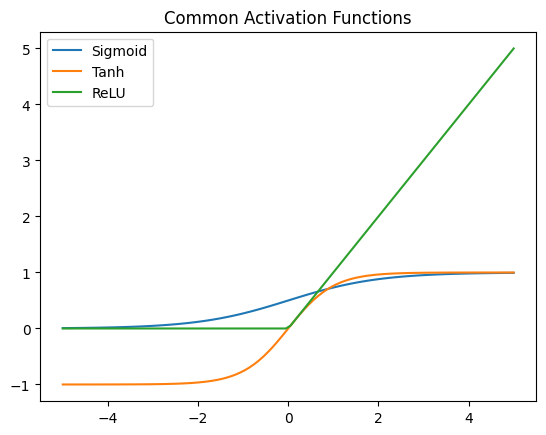

In [17]:
import matplotlib.pyplot as plt
x = torch.linspace(-5, 5, 100)
plt.plot(x, torch.sigmoid(x), label="Sigmoid")
plt.plot(x, torch.tanh(x), label="Tanh")
plt.plot(x, F.relu(x), label="ReLU")
plt.title('Common Activation Functions')
plt.legend()
plt.show()

## <span style="color:blue"><b>Loss Functions</b></span>

- <span style="color:blue"><b>CrossEntropyLoss</b></span> for multi-class classification (combines Softmax + negative log-likelihood)
- <span style="color:blue"><b>MSELoss</b></span> for regression
- <span style="color:blue"><b>BCELoss</b></span> for binary classification

## Loss Functions
A loss function takes the truth value (`y`) and a prediction (`ŷ`) as an input and produce a real-valued score. The lower this score, the better the model is. Some of the most common loss functions in PyTorch are the following.

For more details check: https://pytorch.org/docs/stable/nn.functional.html#loss-functions

### Mean Squared Error Loss
When the out put (`y`) and the prediction (`ŷ`)  are continous values, we can use mean squared error (`MSE`).

$L_{MSE}(y, ŷ) = \frac{1}{n} \sum_{i=1}^{n} ({y-ŷ})^2$

In [18]:
mse_loss = nn.MSELoss()
#predictions
outputs = torch.tensor([2,3], dtype=torch.float, requires_grad=True)
print("Outpusts-->", outputs)

#ground truth
targets = torch.tensor([1.5, 2.5],dtype=torch.float)
print("Targets-->", targets)
loss = mse_loss(outputs, targets)
loss.backward()
print("loss-->",loss)

Outpusts--> tensor([2., 3.], requires_grad=True)
Targets--> tensor([1.5000, 2.5000])
loss--> tensor(0.2500, grad_fn=<MseLossBackward0>)


### Categorical Cross-Entropy Loss

Categorical cross-entropy is a loss function that is used in multi-class classification tasks. 
The categorical cross-entropy loss function calculates the loss of an example by computing the following sum:
$L_{CE}(y, ŷ) = - \sum_{i=1}^{n} {y_i} . log ({ŷ})$

In [19]:
ce_loss = nn.CrossEntropyLoss()
outputs = torch.tensor([[1,4,5,3,2],[3,6,4,5,6],[1,9,5,5,6]], dtype=torch.float, requires_grad=True)

print ("outputs-->",outputs)
targets = torch.tensor([1, 0, 3], dtype=torch.int64)
loss = ce_loss(outputs, targets)
loss.backward()
print ("Losses -->", loss)

outputs--> tensor([[1., 4., 5., 3., 2.],
        [3., 6., 4., 5., 6.],
        [1., 9., 5., 5., 6.]], requires_grad=True)
Losses --> tensor(3.1575, grad_fn=<NllLossBackward0>)


### [Binary Cross-Entropy Loss](https://towardsdatascience.com/understanding-binary-cross-entropy-log-loss-a-visual-explanation-a3ac6025181a)

In [20]:
bce_loss = nn.BCELoss()
sigmoid = nn.Sigmoid()
probabilities = sigmoid(torch.randn(4, 1, requires_grad=True))
print(probabilities)

targets = torch.tensor([1, 0, 1, 0], dtype=torch.float32).view(4, 1)
loss = bce_loss(probabilities, targets)
loss.backward()
print(loss)

tensor([[0.7637],
        [0.5627],
        [0.1917],
        [0.8214]], grad_fn=<SigmoidBackward0>)
tensor(1.1178, grad_fn=<BinaryCrossEntropyBackward0>)


In [21]:
loss_fn = nn.CrossEntropyLoss()
output_logits = torch.tensor([[1.9, 1.1, 0.2]]) # Example: 3-class unnormalized prediction
target = torch.tensor([0])
print("Cross-Entropy Loss:", loss_fn(output_logits, target).item())

Cross-Entropy Loss: 0.48981398344039917


## <span style="color:blue"><b>Optimizers</b></span> & Training Loop

Optimizers adjust model weights to minimize loss.  
Most popular: <span style="color:blue"><b>Adam</b></span>, <span style="color:blue"><b>SGD</b></span>.

# Optimizers
The optimizer tie together the loss function and model parameters by updating the model in response to the output of the loss function. The following are the main steps for optimizers:
1. Calculate what a small change in each individual weight would do to the loss function 
1. Adjust each individual weight based on its gradient (i.e. take a small step in the determined direction)
1. Keep doing steps #1 and #2 until the loss function gets as low as possible

Learning rates can help to regularize the change weights for a better convergence.
![Learning_rate](learningrate.png)

Optimizers in PyTorch: 
Few commonly used ones are:
* Adam
* Adagrad 
* RMSprop
* SGD ...

For complete list check: https://pytorch.org/docs/stable/optim.html#

# Epochs and Batches

During training, we need to update the parameters in iterations.  <span style="color:blue">An iteration</span> in neural network training is one parameter update step. That is, in each iteration, <span style="color:blue">each parameter is updated once</span>. To do so, we divide the training data into different min-batches. 

<span style="color:blue">An epoch</span> is a measure of the number of times all training data is used once to update the parameters.

<span style="color:blue"><b>Optimizers: How Model Weights Learn from Loss</b></span>

- <span style="color:blue"><b>Optimizers</b> (like Adam, SGD) control <b>how</b> your model weights change to minimize loss.</span>
- Each optimizer shapes the update rule, step size, and sometimes keeps “memory” as it trains.
- <span style="color:blue"><b>Learning rate</b> is the most crucial training hyperparameter: too high means unstable, too low = slow or stuck!</span>

Typical Optimizers in PyTorch

| Optimizer    | Best for…                |
|--------------|-------------------------|
| SGD          | Simplicity; baselines   |
| Adam         | Most models; fast, robust; auto-tunes learning |
| RMSprop      | RNNs, tricky gradients  |

<span style="color:blue">Each batch, PyTorch:</span>
1. Runs model on a mini-batch,  
2. Calculates loss, computes gradients,  
3. Updates the weights using the optimizer,  
4. Repeats (many epochs) until happy.

In [22]:
import torch
import torch.nn as nn
X = torch.randn(10, 5)  # 10 samples, 5 features
y = torch.randint(0, 2, (10,))  # 10 targets, binary class
# simple 1-layer model
model = nn.Linear(5, 2)
loss_fn = nn.CrossEntropyLoss()
# Try both optimizers
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
# optimizer = torch.optim.SGD(model.parameters(), lr=0.1)
for epoch in range(2):
    # Forward
    outputs = model(X)
    loss = loss_fn(outputs, y)
    # Backward
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    print(f"Epoch {epoch+1}, loss={loss.item():.4f}")


Epoch 1, loss=0.8216
Epoch 2, loss=0.8098


##  The <span style="color:blue"><b>Training & Evaluation Workflow</b></span>

1. Feed input through the model
2. Compute loss comparing prediction to the target
3. Calculate gradients via `.backward()`
4. Update parameters with optimizer
5. Repeat for several epochs (passes through the data)
6. Evaluate on held-out test set

In [23]:
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer
import numpy as np
# Use 2 classes for demo (feel free to expand)
cats = ["sci.space", "rec.sport.baseball"]
train = fetch_20newsgroups(subset='train', categories=cats)
vectorizer = CountVectorizer(max_features=1000)
X = vectorizer.fit_transform(train.data).toarray()
y = np.array(train.target)

X_tensor = torch.FloatTensor(X)
y_tensor = torch.LongTensor(y)

model = SimplePerceptron(input_size=X.shape[1], hidden_size=50, num_classes=2)
optimizer = torch.optim.Adam(model.parameters())
loss_fn = nn.CrossEntropyLoss()

for epoch in range(3):
    outputs = model(X_tensor)
    loss = loss_fn(outputs, y_tensor)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

# Evaluation
preds = outputs.argmax(dim=1)
accuracy = (preds == y_tensor).float().mean().item()
print("Training accuracy:", f"{accuracy*100:.2f}%")

Epoch 1, Loss: 0.7173
Epoch 2, Loss: 0.6600
Epoch 3, Loss: 0.6236
Training accuracy: 70.59%


<span style="color:red"><b>EXERCISE</b></span>:  
<span style="color:red">Try changing the hidden layer size (e.g., to 10 or 100) and repeat training.  
How does loss or accuracy change?</span>

In [24]:
if EXERCISE:
    import torch
    import torch.nn as nn
    import torch.nn.functional as F
    import numpy as np
    from sklearn.datasets import fetch_20newsgroups
    from sklearn.feature_extraction.text import CountVectorizer
    cats = ["sci.space", "rec.sport.baseball"]
    train = fetch_20newsgroups(subset='train', categories=cats)
    vectorizer = CountVectorizer(max_features=1000)
    X = vectorizer.fit_transform(train.data).toarray()
    y = np.array(train.target)
    X_tensor = torch.FloatTensor(X)
    y_tensor = torch.LongTensor(y)
    hidden_size = _____  
    num_classes = _____  
    model = SimplePerceptron(input_size=X.shape[1], hidden_size=hidden_size, num_classes=num_classes)
    optimizer = torch.optim.Adam(model.parameters())
    loss_fn = nn.CrossEntropyLoss()
    for epoch in range(3):
        outputs = model(X_tensor)
        loss = loss_fn(outputs, y_tensor)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

    preds = outputs.argmax(dim=1)
    accuracy = (preds == y_tensor).float().mean().item()
    print("Training accuracy:", f"{accuracy*100:.2f}%")

## Reporting Results & Inspection

It's important to inspect not just accuracy, but also confusion matrices, per-class precision/recall/F1, and sample errors.  

---

<span style="color:red"><b>EXERCISE</b></span>

<span style="color:red">Adapt the code to print the classification accuracy for a new test set drawn from the same <code>fetch_20newsgroups</code> categories.</span>

---

In [25]:
if EXERCISE:
    from sklearn.datasets import fetch_20newsgroups
    from sklearn.feature_extraction.text import CountVectorizer
    import torch
    import numpy as np
    cats = ["sci.space", "rec.sport.baseball"]
    test = fetch_20newsgroups(subset='test', categories=cats)
    vectorizer = CountVectorizer(max_features=1000)
    X_test = vectorizer.fit_transform(test.data).toarray()
    y_test = np.array(test.target)
    X_test_tensor = torch.FloatTensor(X_test)
    y_test_tensor = torch.LongTensor(y_test)
    model.eval()
    with torch.no_grad():
        outputs = model(_____)  
    preds = outputs.argmax(dim=1)
    accuracy = (preds == y_test_tensor).float().mean().item()
    print("New test set accuracy:", f"{accuracy*100:.2f}%")

## End-to-End: <span style="color:blue"><b>LSTM for Sequence Classification</b></span> 

A common text classification workflow for NLP is:

- Convert word indices to embeddings
- Feed the sequence into an LSTM
- Use the last hidden state (summary representation of the input sequence)
- Classify with a linear (output) layer

This is a robust way to let the model learn patterns over an entire input sequence. Below is a sketch of a PyTorch classifier that does exactly this:

In [26]:
import torch
import torch.nn as nn
class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_classes):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, embedding_dim)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first=True)
        self.linear = nn.Linear(hidden_dim, num_classes)
    def forward(self, x):
        x = self.emb(x)
        _, (h_n, _) = self.lstm(x)
        h_last = h_n[-1]   # last layer's hidden state
        out = self.linear(h_last)
        return out
# usage:
vocab_size = 20
net = LSTMClassifier(vocab_size, 8, 32, 3)
batch = torch.tensor([[1, 5, 2, 8]])  # shape: (batch_size=1, seq_length=4)
print("Prediction logits:", net(batch))

Prediction logits: tensor([[0.1008, 0.3202, 0.1506]], grad_fn=<AddmmBackward0>)


<span style="color:red"><b>EXERCISE</b></span>:  
<span style="color:red">Add another "sentence" to the batch (so shape is (2, 4)), and run `net(batch)` again.  
 What is the shape of the returned prediction logits? (Hint: Should be `[batch_size, num_classes]`!)</span>

In [27]:
if EXERCISE:
    #... EVERYTHING as before
    batch = _____  # the two sentences here!
    print("Prediction logits:", net(batch))

<span style="color:blue"><b>Efficient Data Loading: Dataset and DataLoader in PyTorch</b></span>

For large datasets or batching sequences:
- <span style="color:blue"><b>Dataset</b> lets you define how you provide samples.</span>
- <span style="color:blue"><b>DataLoader</b> shuffles, batches, and handles multi-process loading for you.</span>

But: <span style="color:blue"><b>NLP batches may mix sequence lengths!</b>  
We need to <b>pad sequences in a batch</b> to the same length for efficient tensor computations.</span>

---

In [28]:
from torch.utils.data import Dataset, DataLoader
import torch.nn.utils.rnn as rnn_utils

class TextDataset(Dataset):
    def __init__(self, X, y):
        self.X = X      # List/array of sequences (list-of-tensors)
        self.y = y      # List of label sequences

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# 2 different-length sequences, tag labels too
X = [torch.randint(0,10,(4,)), torch.randint(0,10,(6,))] # 4 and 6 length
y = [torch.randint(0,3,(4,)), torch.randint(0,3,(6,))] # same for labels
dataset = TextDataset(X, y)

print("X with different length",X)
# Collate function to pad within each batch
def collate_fn(batch):
    Xs, ys = zip(*batch)
    X_pad = rnn_utils.pad_sequence(Xs, batch_first=True, padding_value=0)
    y_pad = rnn_utils.pad_sequence(ys, batch_first=True, padding_value=-1)
    return X_pad, y_pad

loader = DataLoader(dataset, batch_size=2, collate_fn=collate_fn)

for X_pad, y_pad in loader:
    print("X padded", X_pad, "Batch X shape:", X_pad.shape)
    print("Y padded", y_pad, "Batch y shape:", y_pad.shape)
    break

X with different length [tensor([1, 2, 5, 6]), tensor([8, 0, 5, 3, 0, 6])]
X padded tensor([[1, 2, 5, 6, 0, 0],
        [8, 0, 5, 3, 0, 6]]) Batch X shape: torch.Size([2, 6])
Y padded tensor([[ 0,  0,  1,  0, -1, -1],
        [ 0,  0,  1,  1,  2,  1]]) Batch y shape: torch.Size([2, 6])


Why Are <span style="color:blue"><b>Sequence Models</b></span> Powerful for NLP?

- <span style="color:blue"><b>Remember word order and context</b></span>
- <span style="color:blue"><b>Handle inputs of variable length</b></span>
- Foundation of advanced architectures (e.g. Transformers, attention, seq2seq)

## Complete Example : Text Categorization - [The 20 Newsgroups data set](http://qwone.com/~jason/20Newsgroups/)
The 20 Newsgroups data set is a collection of approximately 20,000 newsgroup documents, partitioned (nearly) evenly across 20 different newsgroups. 

In [29]:
import torch
import pandas as pd
import numpy as np
import sklearn


### Dataset

In [30]:
from sklearn.datasets import fetch_20newsgroups
# get sub categories
categories = ["comp.graphics","sci.space","rec.sport.baseball","talk.politics.guns", "soc.religion.christian"]
newsgroups_train = fetch_20newsgroups(subset='train', categories=categories, shuffle=True)
newsgroups_test = fetch_20newsgroups(subset='test', categories=categories,  shuffle=True)

train_df = pd.DataFrame({'text': newsgroups_train.data, 'target': newsgroups_train.target})
test_df = pd.DataFrame({'text': newsgroups_test.data, 'target': newsgroups_test.target})

print('total texts in train:',len(train_df))
print('total texts in test:',len(test_df))

total texts in train: 2919
total texts in test: 1942


In [31]:
train_df.head(5)

,text,target
0,From: khayash@hsc.usc.edu (Ken Hayashida)\nSub...,2
1,From: erikb@idt.unit.no (Erik Brenn)\nSubject:...,0
2,From: haberj@Informatik.TU-Muenchen.DE (Haber ...,0
3,From: ccgwt@trentu.ca (Grant Totten)\nSubject:...,0
4,From: cdt@sw.stratus.com (C. D. Tavares)\nSubj...,4


In [32]:
def preprocess_text(text):
    text = text.lower()
    return ' '.join(text.split()) # remove all white spaces


train_df["text"] = train_df["text"].apply(preprocess_text)
test_df["text"] = test_df["text"].apply(preprocess_text)

train_df.head(5)

,text,target
0,from: khayash@hsc.usc.edu (ken hayashida) subj...,2
1,from: erikb@idt.unit.no (erik brenn) subject: ...,0
2,from: haberj@informatik.tu-muenchen.de (haber ...,0
3,from: ccgwt@trentu.ca (grant totten) subject: ...,0
4,from: cdt@sw.stratus.com (c. d. tavares) subje...,4


### Vectorize

In [33]:
from sklearn.feature_extraction.text import CountVectorizer
from collections import Counter

vocab_counter = Counter()
# words from the training data
for text in train_df["text"]:
    vocab_counter.update(text.split())

VOCAB_SIZE = len(vocab_counter)
VOCAB = vocab_counter.keys()
print("VOCAB_SIZE:", VOCAB_SIZE)

train_docs = train_df["text"].tolist()
count_vectorizer = CountVectorizer(vocabulary=VOCAB).fit(train_docs)

def vectorize(text):
    vec = count_vectorizer.transform([text]).toarray()[0]
    return vec    


VOCAB_SIZE: 87378


### Batching

In [34]:
def get_batch(df, i, batch_size):
    text_input = []
    labels = []
    # Split into different batchs, get the next batch 
    texts = df.text[i*batch_size:i*batch_size+batch_size]
    # get the targets 
    categories = df.target[i*batch_size:i*batch_size+batch_size]
    
    # prepare input vectors
    for text in texts:
        vec = vectorize(text)
        text_input.append(vec)

    # We have 5 categories
    for category in categories:
        labels.append(category)

    # the training and the targets as arrays
    return np.array(text_input),np.array(labels)
#     return torch.FloatTensor(np.array(text_input)),torch.LongTensor(np.array(labels))

### Model Definition

In [35]:
import torch.nn as nn
# define the network
class News_20_Net(nn.Module):
     def __init__(self, input_size=300, hidden_size=100, num_classes=5):
        super(News_20_Net, self).__init__()
        self.layer_1 = nn.Linear(input_size, hidden_size, bias=True)
        self.relu = nn.ReLU()
        self.layer_2 = nn.Linear(hidden_size, hidden_size, bias=True)
        self.output_layer = nn.Linear(hidden_size, num_classes, bias=True)
    # accept input and return an output
     def forward(self, x):
        out = self.layer_1(x)
        out = self.relu(out)
        out = self.layer_2(out)
        out = self.relu(out)
        out = self.output_layer(out)
        return out

### Parameters

In [36]:
# Parameters
learning_rate = 0.01
num_epochs = 3
batch_size = 128
display_step = 1

# Network Parameters
hidden_size = 100      # 1st layer and 2nd layer number of features
input_size = VOCAB_SIZE # Words in vocab
num_classes = 5         # Categories: "graphics","space","baseball","guns", "christian"

news_net = News_20_Net(input_size, hidden_size, num_classes).to("cpu")

# Loss and Optimizer
loss_fn = nn.CrossEntropyLoss()  # This includes the Softmax loss function
optimizer = torch.optim.Adam(news_net.parameters(), lr=learning_rate)  

print(news_net)


News_20_Net(
  (layer_1): Linear(in_features=87378, out_features=100, bias=True)
  (relu): ReLU()
  (layer_2): Linear(in_features=100, out_features=100, bias=True)
  (output_layer): Linear(in_features=100, out_features=5, bias=True)
)


### Train

In [37]:
# Train the Model
def train(model, optimizer, loss_fn, train_data, num_epochs=1, batch_size=8, save_path=None):
    
    for epoch in range(num_epochs):
        
        # determine the number of min-batches based on the batch size and size of training data
        total_batch = int(len(train_data)/batch_size)
        
        # Loop over all batches
        for i in range(total_batch):

            batch_x, batch_y = get_batch(train_data,i,batch_size)
            articles = torch.FloatTensor(batch_x)
            labels = torch.LongTensor(batch_y)

            optimizer.zero_grad()  # zero the gradient buffer
            # Forward + Backward + Optimize
            outputs = model(articles)
            loss = loss_fn(outputs, labels)

            loss.backward()
            optimizer.step()


            if (i+1) % 4 == 0:
                print ('Epoch [%d/%d], Step [%d/%d], Loss: %.4f'
                       %(epoch+1, num_epochs, i+1, 
                         len(train_data)/batch_size, loss.data))
                
    
    if save_path:
        print(f"saving model to {save_path}")
        torch.save(model.state_dict(), f"{save_path}")
    return model  



trained_model = train(news_net, optimizer, loss_fn, train_df, 
                      num_epochs=num_epochs, batch_size=batch_size,
                     save_path="20news_model.pth") 


Epoch [1/3], Step [4/22], Loss: 1.1636
Epoch [1/3], Step [8/22], Loss: 0.5469
Epoch [1/3], Step [12/22], Loss: 0.1978
Epoch [1/3], Step [16/22], Loss: 0.0633
Epoch [1/3], Step [20/22], Loss: 0.1089
Epoch [2/3], Step [4/22], Loss: 0.0361
Epoch [2/3], Step [8/22], Loss: 0.0072
Epoch [2/3], Step [12/22], Loss: 0.0028
Epoch [2/3], Step [16/22], Loss: 0.0012
Epoch [2/3], Step [20/22], Loss: 0.0138
Epoch [3/3], Step [4/22], Loss: 0.0009
Epoch [3/3], Step [8/22], Loss: 0.0007
Epoch [3/3], Step [12/22], Loss: 0.0033
Epoch [3/3], Step [16/22], Loss: 0.0040
Epoch [3/3], Step [20/22], Loss: 0.0001
saving model to 20news_model.pth


In [38]:
#show the different trained parameters
for name, param in trained_model.named_parameters():
    if param.requires_grad:
        print ("Name--->",name,"\nValues--->", param.data)

Name---> layer_1.weight 
Values---> tensor([[ 0.0017, -0.0023, -0.0021,  ...,  0.0004, -0.0033, -0.0024],
        [ 0.0017, -0.0028, -0.0011,  ..., -0.0025,  0.0006, -0.0026],
        [-0.0028,  0.0006,  0.0020,  ...,  0.0003, -0.0006, -0.0023],
        ...,
        [-0.0028, -0.0003,  0.0032,  ...,  0.0031, -0.0009, -0.0009],
        [-0.0011,  0.0031,  0.0024,  ..., -0.0032,  0.0017,  0.0025],
        [-0.0029,  0.0030, -0.0013,  ..., -0.0024,  0.0014, -0.0030]])
Name---> layer_1.bias 
Values---> tensor([-0.0585,  0.0191,  0.0146,  0.0750,  0.0079, -0.0363,  0.0334, -0.0561,
        -0.0354, -0.0089, -0.0537,  0.1046,  0.0452,  0.0262,  0.0282,  0.0581,
         0.0422,  0.0325, -0.0053,  0.0576,  0.0231,  0.0113,  0.0318,  0.0366,
         0.0411,  0.0421,  0.0812,  0.0510,  0.0193,  0.0460,  0.0443,  0.0728,
         0.0788, -0.0571,  0.0282, -0.0614,  0.1031,  0.0142,  0.0424,  0.0364,
         0.0324,  0.0265,  0.0190, -0.0614, -0.0755,  0.0231,  0.0424,  0.0419,
         0.0107,

### Test

In [39]:
def test(model, loss_fn, test_data):
    
    # get all the test dataset as one batch
    batch_x, batch_y = get_batch(test_data, 0, len(test_data))
    articles = torch.FloatTensor(batch_x)
    labels = torch.LongTensor(batch_y)

    model.eval()
    
    with torch.no_grad():
        outputs = model(articles)

    predicted = outputs.argmax(1)
    loss = loss_fn(outputs, labels)
    correct = (predicted == labels).sum()
    total = labels.size(0)
    print(f'Accuracy on %d test articles: %d %%' % (len(test_data), 100 * correct // total))
    print('loss: %f' % (loss))
    
#     return predicted
    
# to load the model, recreate it as a a fresh instance and load the state dict
model = News_20_Net(input_size=input_size).to("cpu")
model.load_state_dict(torch.load("20news_model.pth", weights_only=True))

test(model, loss_fn, test_df)

Accuracy on 1942 test articles: 93 %
loss: 0.377502


#  <span style="color:blue"><b>Model Deployment</b></span>

---

After building and evaluating a <span style="color:blue"><b>PyTorch</b></span> ML model, the next step is sharing your results: via an <span style="color:blue"><b>API (e.g. Flask)</b></span>, a web demo, or a technical report.

<span style="color:blue"><b>Serving Models with Flask</b></span> (REST API Demo)

A minimal <span style="color:blue"><b>Flask</b></span> app can load your trained classifier and provide predictions via HTTP requests.

<span style="color:blue"><b>Putting It All Together: Model Deployment via Flask</b></span>

Once you’ve trained a model, you’ll want to use it in the real world—maybe in a web app, an API, or for batch predictions on new data.

<span style="color:blue">With <b>Flask</b>, you can serve your PyTorch model so others (or your code) can send text and receive predictions via HTTP—no need to re-train or run notebooks for every new prediction!</span>

---

In [ ]:
from flask import Flask, request, jsonify
import torch
import torch.nn as nn

app = Flask(__name__)

# Example model: Replace this with your own!
class DemoModel(nn.Module):
    def __init__(self): 
        super().__init__()
        self.linear = nn.Linear(5, 2)  # input_size, num_classes
    def forward(self, x): 
        return self.linear(x)

model = DemoModel()
model.eval()

@app.route("/predict", methods=["POST"])
def predict():
    data = request.json
    # For demo: take a list of 5 numbers (features)
    x = torch.tensor([data['input']]).float()
    pred = model(x).argmax(dim=1).item()
    return jsonify({'prediction': pred})

# (To run: save this in app.py, then do: python app.py)
# Test via: curl -X POST http://localhost:5000/predict -H "Content-Type: application/json" -d '{"input":[1,2,3,4,5]}'

<span style="color:red"><b>EXERCISE</b></span>:  
<span style="color:red">Replace <code>DemoModel</code> with your own model trained for text classification.  
Adapt the <code>predict()</code> endpoint to accept raw text input, preprocess, vectorize, and predict its class label.</span>

# Resources 
* [Pytorch Tutorial](https://speech.ee.ntu.edu.tw/~hylee/ml/ml2022-course-data/Pytorch%20Tutorial%201.pdf)
* [Custom NER using spaCy](https://medium.com/@manivannan_data/how-to-train-ner-with-custom-training-data-using-spacy-188e0e508c6)
* [Custom NER using spaCy](https://github.com/Jcharis/Natural-Language-Processing-Tutorials/blob/master/Training%20the%20Named%20Entity%20Recognizer%20in%20SpaCy.ipynb)
* [Overview of PyTorch](https://www.learnopencv.com/pytorch-for-beginners-basics/)
* [Perceptron in PyTorch](https://medium.com/@tomgrek/building-your-first-neural-net-from-scratch-with-pytorch-56b0e9c84d54)
* [Data Loading and processing in PyTorch](https://pytorch.org/tutorials/beginner/data_loading_tutorial.html)
* [PyTorch resources](https://github.com/ritchieng/the-incredible-pytorch)
* [PyTorch Tutorial](https://github.com/yunjey/pytorch-tutorial)
* [A Beginner-Friendly Guide to PyTorch and How it Works from Scratch](https://medium.com/analytics-vidhya/a-beginner-friendly-guide-to-pytorch-and-how-it-works-from-scratch-25c7c2dceb30)
* [RNN  Tutorial](https://blog.floydhub.com/a-beginners-guide-on-recurrent-neural-networks-with-pytorch/)
* [PyTorch Tutorial](https://pythonprogramming.net/introduction-deep-learning-neural-network-pytorch/)
* [NER API Flask](https://github.com/susanli2016/Named-Entity-Extractor)